# FASE 3: EDA para clasificacion direccional con SVC (multihorizonte)

Contexto metodologico de esta fase:
- Se usa solo la serie observada de trading (sin forward filling).
- El EDA se centra en un problema de clasificacion SVC, no en regresion SVR.
- Se evaluan simultaneamente horizontes de 1, 5 y 20 pasos de trading.
- El objetivo es decidir despues, con evidencia, que horizonte/modelo es mas defendible.

In [49]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf

pd.set_option('display.max_columns', 220)
pd.set_option('display.width', 260)
sns.set_theme(style='whitegrid')

## 1. Carga y serie por eventos
Se construye la serie por dia de trading (ultimo precio por fecha observada), sin imputacion, y se prepara el set base para analisis multihorizonte.

In [50]:
# Configuracion base
empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'
HORIZONS = [1, 5, 20]

In [51]:
df = pd.read_csv('data/processed/BVG_Acciones_limpio.csv')
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')

print('Shape filtrado:', df.shape)
print('Rango fechas:', df[fecha_col].min(), '->', df[fecha_col].max())
display(df[[fecha_col, emisor_col, precio_col]].head())

Shape filtrado: (18188, 11)
Rango fechas: 2019-01-02 00:00:00 -> 2026-03-25 00:00:00


,FECHA NEGOCIACIÓN,EMISOR,PRECIO
0,2019-01-02,BANCO GUAYAQUIL S.A.,0.96
1,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
2,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
3,2019-01-14,BANCO GUAYAQUIL S.A.,0.96
4,2019-01-14,BANCO GUAYAQUIL S.A.,0.95


In [52]:
# Serie por eventos (trading days) sin imputacion
rows_event = []

for empresa in empresas_objetivo:
    g = df[df[emisor_col] == empresa].copy()

    diario_trade = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=False)[precio_col]
        .last()
        .rename(columns={fecha_col: 'fecha', precio_col: 'precio_trade_day'})
        .sort_values('fecha')
        .reset_index(drop=True)
    )

    diario_trade['ret'] = np.log(diario_trade['precio_trade_day'] / diario_trade['precio_trade_day'].shift(1))
    diario_trade['abs_ret'] = diario_trade['ret'].abs()
    diario_trade['delta_t'] = diario_trade['fecha'].diff().dt.days
    diario_trade['empresa'] = empresa
    rows_event.append(diario_trade)

df_ret = pd.concat(rows_event, ignore_index=True)
display(df_ret.head())

,fecha,precio_trade_day,ret,abs_ret,delta_t,empresa
0,2019-01-02,2.44,NaN,NaN,NaN,CORPORACION FAVORITA C.A.
1,2019-01-03,2.46,0.008163,0.008163,1.0,CORPORACION FAVORITA C.A.
2,2019-01-04,2.44,-0.008163,0.008163,1.0,CORPORACION FAVORITA C.A.
3,2019-01-07,2.45,0.004090,0.004090,3.0,CORPORACION FAVORITA C.A.
4,2019-01-09,2.44,-0.004090,0.004090,2.0,CORPORACION FAVORITA C.A.


## 2. Calidad de muestra para clasificacion
Se cuantifica densidad de eventos, irregularidad temporal y tamano de muestra efectivo por emisor.

In [53]:
rows = []
for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].sort_values('fecha').copy()

    n_ret = int(d['ret'].notna().sum())
    n_trade_days = int(d['precio_trade_day'].notna().sum())
    fecha_min = d['fecha'].min()
    fecha_max = d['fecha'].max()
    span_days = int((fecha_max - fecha_min).days) + 1 if pd.notna(fecha_min) and pd.notna(fecha_max) else np.nan
    densidad = (n_trade_days / span_days) if span_days and span_days > 0 else np.nan

    dt = d['delta_t'].dropna()
    mean_dt = float(dt.mean()) if len(dt) > 0 else np.nan
    p90_dt = float(dt.quantile(0.90)) if len(dt) > 0 else np.nan

    rows.append({
        'empresa': empresa,
        'n_ret': n_ret,
        'n_trade_days': n_trade_days,
        'densidad_eventos': densidad,
        'mean_delta_t_days': mean_dt,
        'p90_delta_t_days': p90_dt
    })

muestra_df = pd.DataFrame(rows)
display(muestra_df)

,empresa,n_ret,n_trade_days,densidad_eventos,mean_delta_t_days,p90_delta_t_days
0,CORPORACION FAVORITA C.A.,1702,1703,0.645076,1.550529,3.0
1,BANCO GUAYAQUIL S.A.,1167,1168,0.442424,2.261354,5.0


## 3. Distribucion de retornos por eventos
Se evalua forma de distribucion (media, dispersion, sesgo, curtosis) para anticipar dificultad de separacion en SVC.

In [54]:
stats_rows = []

for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].copy()
    s = d['ret'].dropna()

    stats_rows.append({
        'empresa': empresa,
        'n': int(len(s)),
        'mean': float(s.mean()) if len(s) > 0 else np.nan,
        'std': float(s.std()) if len(s) > 0 else np.nan,
        'skew': float(s.skew()) if len(s) > 0 else np.nan,
        'kurtosis': float(s.kurtosis()) if len(s) > 0 else np.nan,
        'q01': float(s.quantile(0.01)) if len(s) > 0 else np.nan,
        'q99': float(s.quantile(0.99)) if len(s) > 0 else np.nan
    })
    
stats_ret_df = pd.DataFrame(stats_rows)
display(stats_ret_df)

,empresa,n,mean,std,skew,kurtosis,q01,q99
0,CORPORACION FAVORITA C.A.,1702,-0.000117,0.015761,-1.109285,29.012524,-0.043485,0.045114
1,BANCO GUAYAQUIL S.A.,1167,0.000741,0.030682,-0.353466,14.363538,-0.096374,0.095310


## 4. Regimen de volatilidad en el tiempo
Se visualiza volatilidad rolling para ventanas corta, media y larga (5, 10 y 20) como contexto para SVC.

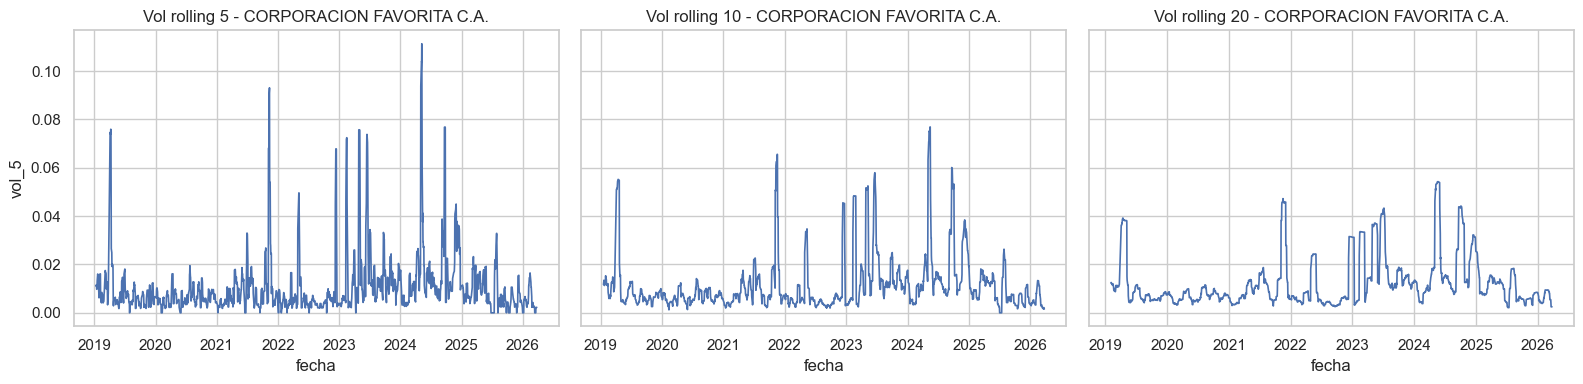

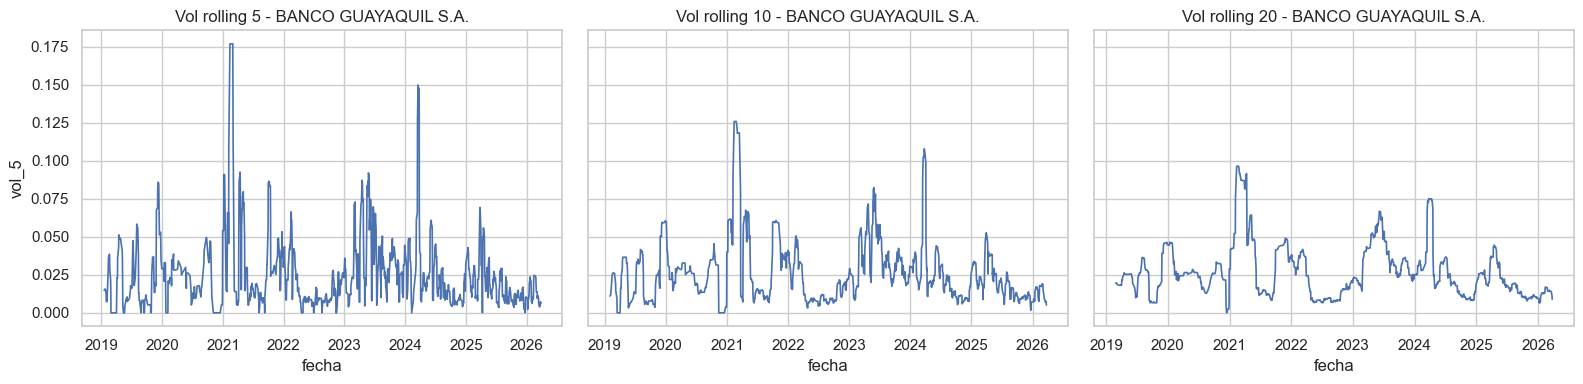

In [55]:
ventanas_vol = [5, 10, 20]

for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].sort_values('fecha').copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for i, w in enumerate(ventanas_vol):
        col = f'vol_{w}'
        d[col] = d['ret'].rolling(window=w, min_periods=w).std()
        sns.lineplot(data=d, x='fecha', y=col, ax=axes[i], linewidth=1.2)
        axes[i].set_title(f'Vol rolling {w} - {empresa}')

    plt.tight_layout()
    plt.show()

## 5. Dependencia temporal de corto plazo
Se calcula ACF y PACF para verificar si hay estructura temporal explotable para clasificacion direccional.

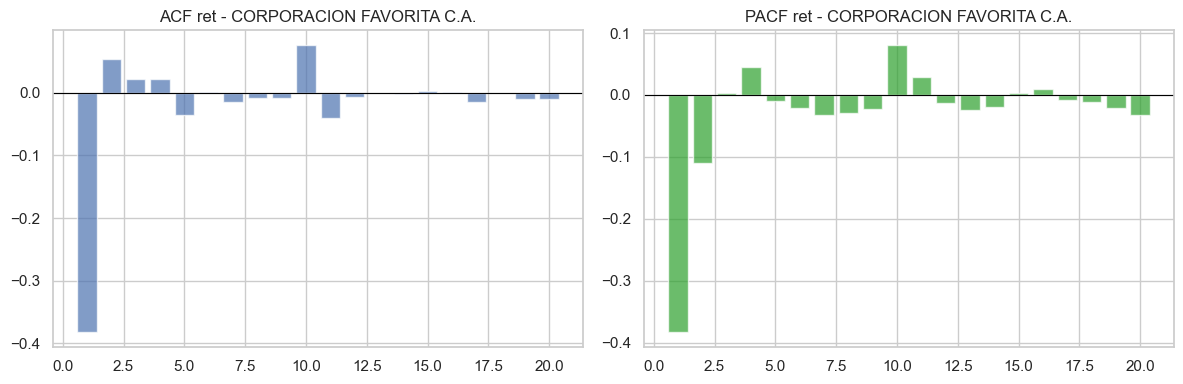

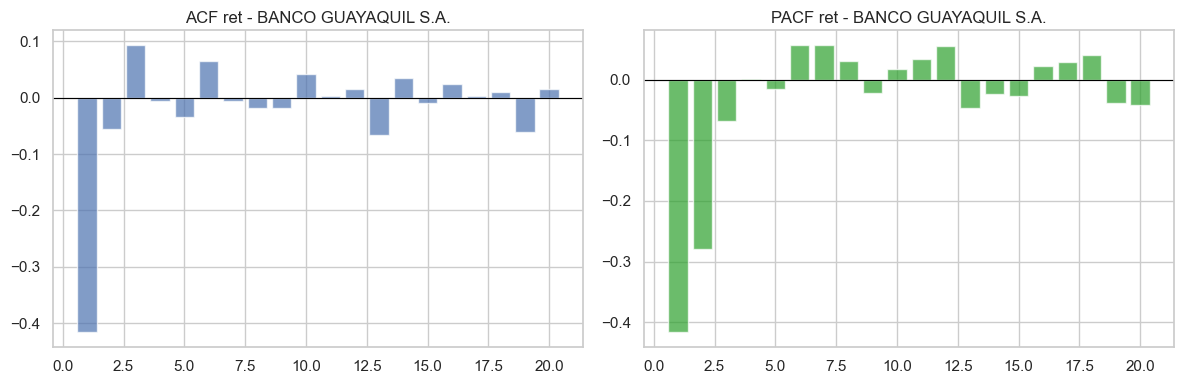

,empresa,lag,acf
0,CORPORACION FAVORITA C.A.,1,-0.382881
1,CORPORACION FAVORITA C.A.,2,0.053403
2,CORPORACION FAVORITA C.A.,3,0.022076
3,CORPORACION FAVORITA C.A.,4,0.021596
4,CORPORACION FAVORITA C.A.,5,-0.035519


,empresa,lag,pacf
0,CORPORACION FAVORITA C.A.,1,-0.383106
1,CORPORACION FAVORITA C.A.,2,-0.109355
2,CORPORACION FAVORITA C.A.,3,0.003492
3,CORPORACION FAVORITA C.A.,4,0.045246
4,CORPORACION FAVORITA C.A.,5,-0.009546


In [56]:
acf_rows = []
pacf_rows = []

for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].copy()
    s = d['ret'].dropna()

    acf_vals = acf(s, nlags=20, fft=True, missing='drop')
    pacf_vals = pacf(s, nlags=20, method='yw')
    lags = np.arange(1, 21)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(lags, acf_vals[1:], alpha=0.7)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'ACF ret - {empresa}')

    axes[1].bar(lags, pacf_vals[1:], alpha=0.7, color='tab:green')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'PACF ret - {empresa}')
    plt.tight_layout()
    plt.show()

    for lag in range(1, 21):
        acf_rows.append({'empresa': empresa, 'lag': lag, 'acf': float(acf_vals[lag])})
        pacf_rows.append({'empresa': empresa, 'lag': lag, 'pacf': float(pacf_vals[lag])})

acf_df = pd.DataFrame(acf_rows)
pacf_df = pd.DataFrame(pacf_rows)
display(acf_df.head())
display(pacf_df.head())

## 6. Targets direccionales multihorizonte (1, 5, 20)
Se construyen etiquetas binarias de direccion para cada horizonte en pasos de trading, y se reporta su equivalente en dias calendario.

In [57]:
# Construccion de panel multihorizonte para SVC
rows_h = []

for empresa in empresas_objetivo:
    g = (
        df[df[emisor_col] == empresa]
        .sort_values(fecha_col)
        .groupby(fecha_col, as_index=False)[precio_col]
        .last()
        .rename(columns={fecha_col: 'fecha', precio_col: 'precio_trade_day'})
        .sort_values('fecha')
        .reset_index(drop=True)
    )

    for h in HORIZONS:
        tmp = g.copy()
        tmp['horizon'] = h
        tmp['fecha_t_h'] = tmp['fecha'].shift(-h)
        tmp['precio_t_h'] = tmp['precio_trade_day'].shift(-h)
        tmp['ret_fwd_h'] = np.log(tmp['precio_t_h'] / tmp['precio_trade_day'])
        tmp['target_up_h'] = np.where(tmp['ret_fwd_h'].notna(), (tmp['ret_fwd_h'] > 0).astype(int), np.nan)
        tmp['delta_cal_t_to_t_h'] = (tmp['fecha_t_h'] - tmp['fecha']).dt.days
        tmp['empresa'] = empresa
        rows_h.append(tmp)

df_h = pd.concat(rows_h, ignore_index=True)
display(df_h[['fecha', 'empresa', 'horizon', 'ret_fwd_h', 'target_up_h', 'delta_cal_t_to_t_h']].head())

,fecha,empresa,horizon,ret_fwd_h,target_up_h,delta_cal_t_to_t_h
0,2019-01-02,CORPORACION FAVORITA C.A.,1,0.008163,1.0,1.0
1,2019-01-03,CORPORACION FAVORITA C.A.,1,-0.008163,0.0,1.0
2,2019-01-04,CORPORACION FAVORITA C.A.,1,0.004090,1.0,3.0
3,2019-01-07,CORPORACION FAVORITA C.A.,1,-0.004090,0.0,2.0
4,2019-01-09,CORPORACION FAVORITA C.A.,1,0.020285,1.0,1.0


## 7. Diagnostico comparativo por horizonte
Se compara balance de clases, dispersion, colas y conversion a dias calendario para cada horizonte y emisor.

In [58]:
h_summary_rows = []

for empresa in empresas_objetivo:
    for h in HORIZONS:
        d = df_h[(df_h['empresa'] == empresa) & (df_h['horizon'] == h)].copy()
        d = d[d['ret_fwd_h'].notna()].copy()

        y = d['target_up_h']
        r = d['ret_fwd_h']
        dt = d['delta_cal_t_to_t_h']

        p_up = float(y.mean()) if len(y) > 0 else np.nan
        p_down = 1.0 - p_up if pd.notna(p_up) else np.nan
        imbalance = abs(p_up - 0.5) if pd.notna(p_up) else np.nan

        q20_abs = float(r.abs().quantile(0.20)) if len(r) > 0 else np.nan
        frac_low_signal = float((r.abs() <= q20_abs).mean()) if pd.notna(q20_abs) else np.nan

        h_summary_rows.append({
            'empresa': empresa,
            'horizon': h,
            'n_valid': int(len(d)),
            'p_up': p_up,
            'p_down': p_down,
            'class_imbalance_abs': imbalance,
            'ret_std': float(r.std()) if len(r) > 0 else np.nan,
            'ret_kurtosis': float(r.kurtosis()) if len(r) > 0 else np.nan,
            'frac_low_signal_labels': frac_low_signal,
            'delta_cal_median_days': float(dt.median()) if len(dt) > 0 else np.nan,
            'delta_cal_p90_days': float(dt.quantile(0.90)) if len(dt) > 0 else np.nan
        })

h_summary_df = pd.DataFrame(h_summary_rows).sort_values(['empresa', 'horizon']).reset_index(drop=True)
display(h_summary_df)

,empresa,horizon,n_valid,p_up,p_down,class_imbalance_abs,ret_std,ret_kurtosis,frac_low_signal_labels,delta_cal_median_days,delta_cal_p90_days
0,BANCO GUAYAQUIL S.A.,1,1167,0.330763,0.669237,0.169237,0.030682,14.363538,0.381320,1.0,5.0
1,BANCO GUAYAQUIL S.A.,5,1163,0.445400,0.554600,0.054600,0.040017,6.773372,0.249355,10.0,16.8
2,BANCO GUAYAQUIL S.A.,20,1148,0.533972,0.466028,0.033972,0.073551,1.838934,0.202091,41.0,63.0
3,CORPORACION FAVORITA C.A.,1,1702,0.310811,0.689189,0.189189,0.015761,29.012524,0.367215,1.0,3.0
4,CORPORACION FAVORITA C.A.,5,1698,0.368669,0.631331,0.131331,0.024388,18.203663,0.216726,7.0,10.0
5,CORPORACION FAVORITA C.A.,20,1683,0.415924,0.584076,0.084076,0.043126,3.099593,0.200238,30.0,35.0


=== RESUMEN EDA SVC MULTIHORIZONTE ===
                  empresa  horizon  n_valid     p_up   p_down  class_imbalance_abs  ret_std  ret_kurtosis  frac_low_signal_labels  delta_cal_median_days  delta_cal_p90_days
     BANCO GUAYAQUIL S.A.        1     1167 0.330763 0.669237             0.169237 0.030682     14.363538                0.381320                    1.0                 5.0
     BANCO GUAYAQUIL S.A.        5     1163 0.445400 0.554600             0.054600 0.040017      6.773372                0.249355                   10.0                16.8
     BANCO GUAYAQUIL S.A.       20     1148 0.533972 0.466028             0.033972 0.073551      1.838934                0.202091                   41.0                63.0
CORPORACION FAVORITA C.A.        1     1702 0.310811 0.689189             0.189189 0.015761     29.012524                0.367215                    1.0                 3.0
CORPORACION FAVORITA C.A.        5     1698 0.368669 0.631331             0.131331 0.024388     

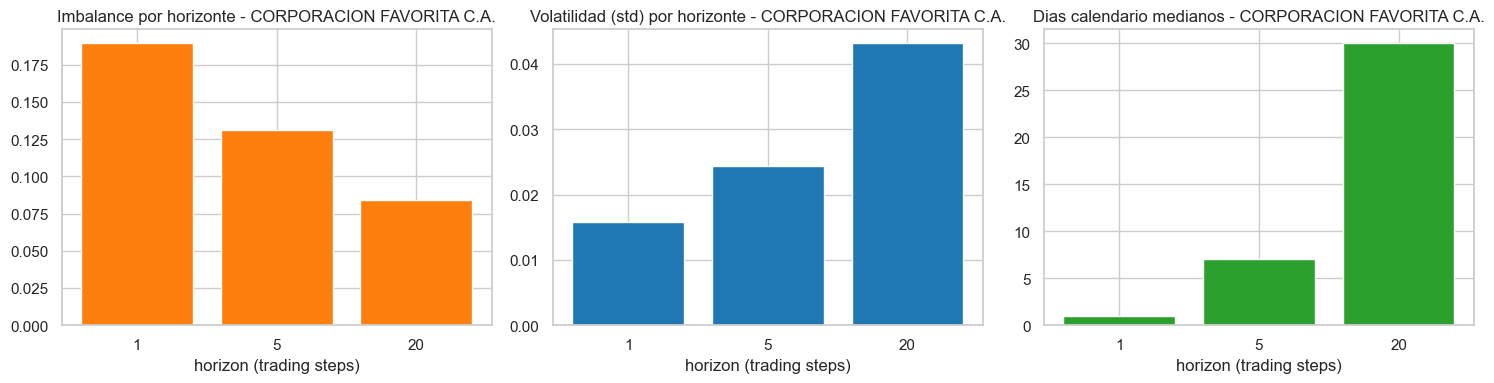

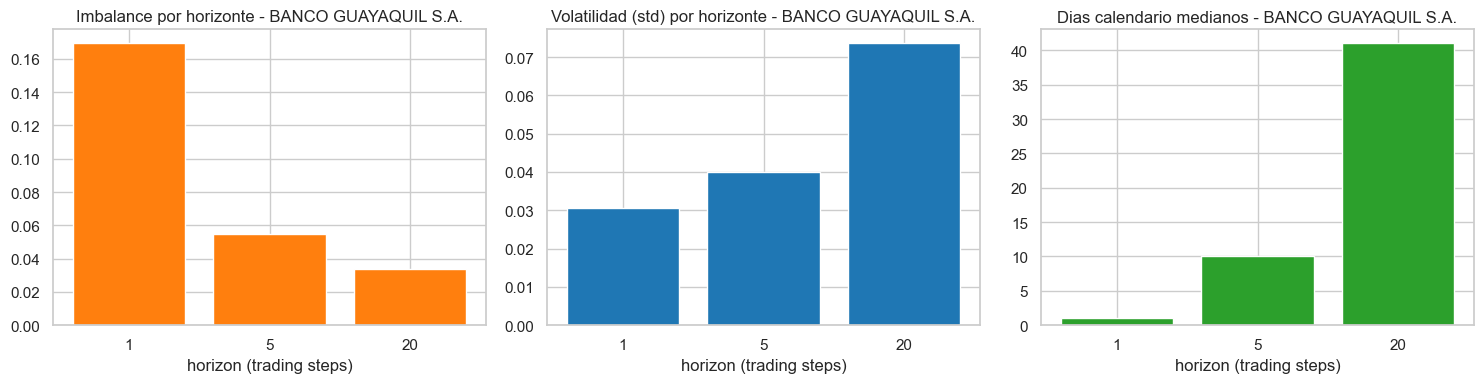

In [59]:
print('=== RESUMEN EDA SVC MULTIHORIZONTE ===')
print(h_summary_df.to_string(index=False))

print('\n=== LECTURA RAPIDA POR EMPRESA ===')
for empresa in empresas_objetivo:
    s = h_summary_df[h_summary_df['empresa'] == empresa].sort_values('horizon').copy()
    print(f'\nEmpresa: {empresa}')
    for _, r in s.iterrows():
        print(
            f"- h={int(r['horizon'])}: n={int(r['n_valid'])}, "
            f"imbalance={r['class_imbalance_abs']:.3f}, "
            f"std={r['ret_std']:.4f}, kurt={r['ret_kurtosis']:.2f}, "
            f"med_cal={r['delta_cal_median_days']:.1f}, p90_cal={r['delta_cal_p90_days']:.1f}"
        )

# Visual comparativo minimo y util para decidir luego en fase de modelado
for empresa in empresas_objetivo:
    s = h_summary_df[h_summary_df['empresa'] == empresa].sort_values('horizon').copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(s['horizon'].astype(str), s['class_imbalance_abs'], color='tab:orange')
    axes[0].set_title(f'Imbalance por horizonte - {empresa}')

    axes[1].bar(s['horizon'].astype(str), s['ret_std'], color='tab:blue')
    axes[1].set_title(f'Volatilidad (std) por horizonte - {empresa}')

    axes[2].bar(s['horizon'].astype(str), s['delta_cal_median_days'], color='tab:green')
    axes[2].set_title(f'Dias calendario medianos - {empresa}')

    for ax in axes:
        ax.set_xlabel('horizon (trading steps)')

    plt.tight_layout()
    plt.show()

## 8. Conclusiones de fase

### 1. Hallazgos cuantitativos clave

- La muestra efectiva sigue siendo suficiente para analisis SVC en los 3 horizontes, pero con asimetria entre emisores:
  - CORPORACION FAVORITA C.A.: `n_ret=1702`, `densidad_eventos=0.645`, `p90_delta_t=3` dias.
  - BANCO GUAYAQUIL S.A.: `n_ret=1167`, `densidad_eventos=0.442`, `p90_delta_t=5` dias.
- Los retornos mantienen colas pesadas, especialmente en horizontes cortos:
  - Favorita: `kurtosis ret_event=29.01`.
  - Banco Guayaquil: `kurtosis ret_event=14.36`.
- En comparacion multihorizonte (`h=1, 5, 20`) se observa un patron estable:
  - A mayor horizonte, menor desbalance de clases (`class_imbalance_abs` baja).
  - A mayor horizonte, menor curtosis del retorno futuro (`ret_kurtosis` baja).
  - A mayor horizonte, mayor dispersion (`ret_std` sube) y mayor desfase calendario (`delta_cal_median_days` sube fuerte).

### 2. Observaciones de horizontes

- `h=1` conserva mayor cercania temporal (mediana calendario = 1 dia), pero con mayor desbalance y colas mas extremas.
- `h=5` actua como punto intermedio: reduce ruido extremo frente a `h=1` sin llegar al desfase calendario tan alto de `h=20`.
- `h=20` mejora balance y forma de distribucion, pero introduce una latencia operacional alta (30-41 dias medianos, hasta 63 dias en p90 para Banco).

### 3. Riesgos identificados

- Riesgo de heterogeneidad por liquidez entre emisores (Banco mas irregular).
- Riesgo de comparar modelos con criterio sesgado si no se usa exactamente el mismo protocolo de entrenamiento/evaluacion para `h=1,5,20`.
- Riesgo de sobreinterpretar solo balance de clases: mejor balance no implica automaticamente mejor desempeno predictivo out-of-sample.
